# 01 — EDA & Behavioral Baselines
**PS-04: Data Access Audit & Insider Threat Detection**

Exploratory analysis of the access logs and user profiles, plus the per-user behavioral baselines. All logic is imported from `src/` — nothing is redefined here.

Run top-to-bottom with **Kernel → Restart & Run All**.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))  # import config / src from the repo root
warnings.filterwarnings('ignore')
%matplotlib inline
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='viridis')

import config
from src.ingestor import load_access_logs, load_user_profiles, merge_logs_with_profiles
from src.baseline import build_all_baselines
from src.labeler import label_all_events
print('imports OK')

imports OK


## 1. Data overview
Shapes, dtypes, null counts, date range, cardinalities.

In [2]:
logs = load_access_logs()
profiles = load_user_profiles()
df = merge_logs_with_profiles(logs, profiles)
print('logs    :', logs.shape)
print('profiles:', profiles.shape)
print('merged  :', df.shape)
print('date range:', logs['timestamp'].min(), '->', logs['timestamp'].max(),
      '(%d days)' % (logs['timestamp'].max() - logs['timestamp'].min()).days)
print('unique users    :', logs['user_id'].nunique())
print('unique resources:', logs['resource'].nunique())
print('avg events/user :', round(len(logs) / logs['user_id'].nunique(), 1))

logs    : (1200, 9)
profiles: (100, 13)
merged  : (1200, 20)
date range: 2025-04-21 05:58:00+00:00 -> 2026-04-20 10:54:06+00:00 (364 days)
unique users    : 100
unique resources: 10
avg events/user : 12.0


In [3]:
null_summary = pd.DataFrame({'logs_nulls': logs.isna().sum()})
print('Null counts (logs) — all zero in the shipped data:')
print(logs.isna().sum().to_string())
print('\nNull counts (profiles):')
print(profiles.isna().sum().to_string())
logs.dtypes

Null counts (logs) — all zero in the shipped data:
timestamp               0
user_id                 0
username                0
action                  0
resource                0
resource_sensitivity    0
status                  0
source_ip               0
time_classification     0

Null counts (profiles):
user_id                0
username               0
email                  0
department             0
job_title              0
privilege_level        0
systems_access         0
last_login             0
days_inactive          0
is_active              0
hire_date              0
systems_access_list    0
tenure_months          0


timestamp               datetime64[ns, UTC]
user_id                              object
username                             object
action                               object
resource                             object
resource_sensitivity                 object
status                               object
source_ip                            object
time_classification                  object
dtype: object

## 2. Access-pattern distributions
How activity breaks down by time classification, sensitivity, action, and department.

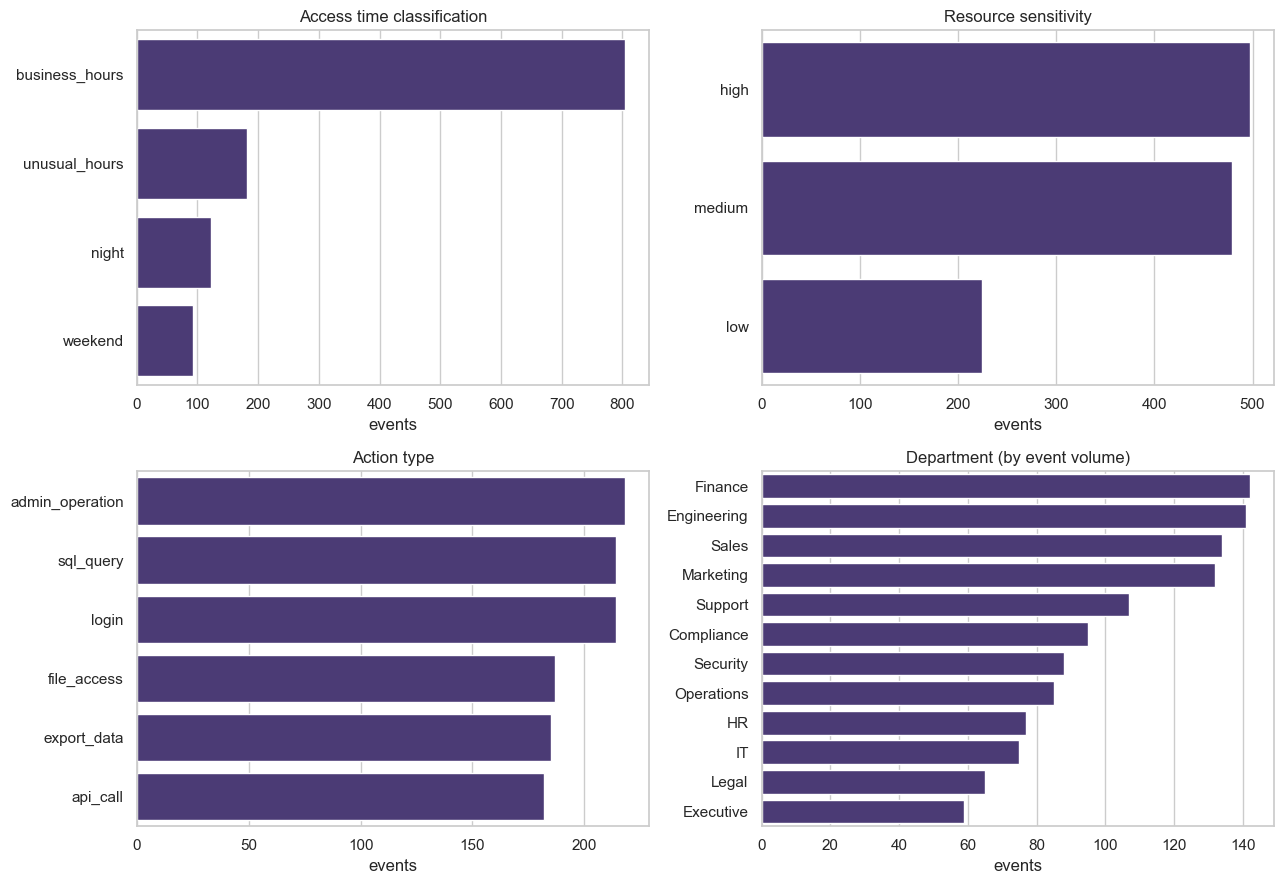

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
panels = [('time_classification', 'Access time classification'),
          ('resource_sensitivity', 'Resource sensitivity'),
          ('action', 'Action type'),
          ('department', 'Department (by event volume)')]
for ax, (col, title) in zip(axes.flat, panels):
    vc = df[col].value_counts()
    sns.barplot(x=vc.values, y=vc.index, ax=ax)
    ax.set_title(title); ax.set_xlabel('events'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

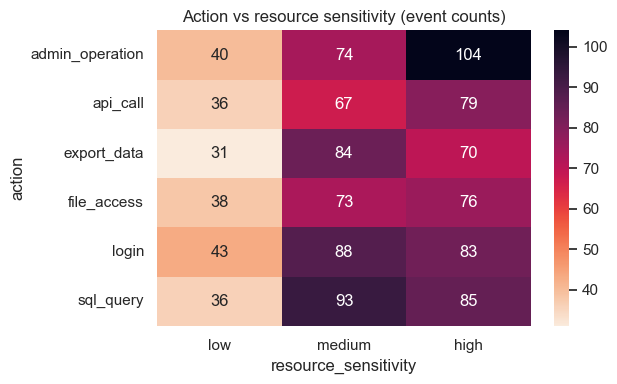

In [5]:
ct = pd.crosstab(df['action'], df['resource_sensitivity'])[['low', 'medium', 'high']]
plt.figure(figsize=(6.5, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='rocket_r')
plt.title('Action vs resource sensitivity (event counts)')
plt.tight_layout(); plt.show()

## 3. Per-user behavioral baselines
Baselines are built from each user's **full history** (the data is ~12 events/user/year, too sparse for a 30-day window) with a cohort fallback. Below are three high-activity users.

In [6]:
baselines = build_all_baselines(df, profiles)
examples = sorted(baselines.values(), key=lambda b: -b['event_count'])[:3]
summary = pd.DataFrame([{
    'user_id': b['user_id'], 'privilege': b['privilege_level'], 'events': b['event_count'],
    'distinct_ips': len(b['seen_ips_own']), 'distinct_resources': len(b['typical_resources_own']),
    'low_confidence': b['low_confidence'],
} for b in examples])
summary

,user_id,privilege,events,distinct_ips,distinct_resources,low_confidence
0,USR00011,user,20,20,10,False
1,USR00001,user,19,19,8,False
2,USR00048,user,19,19,9,False


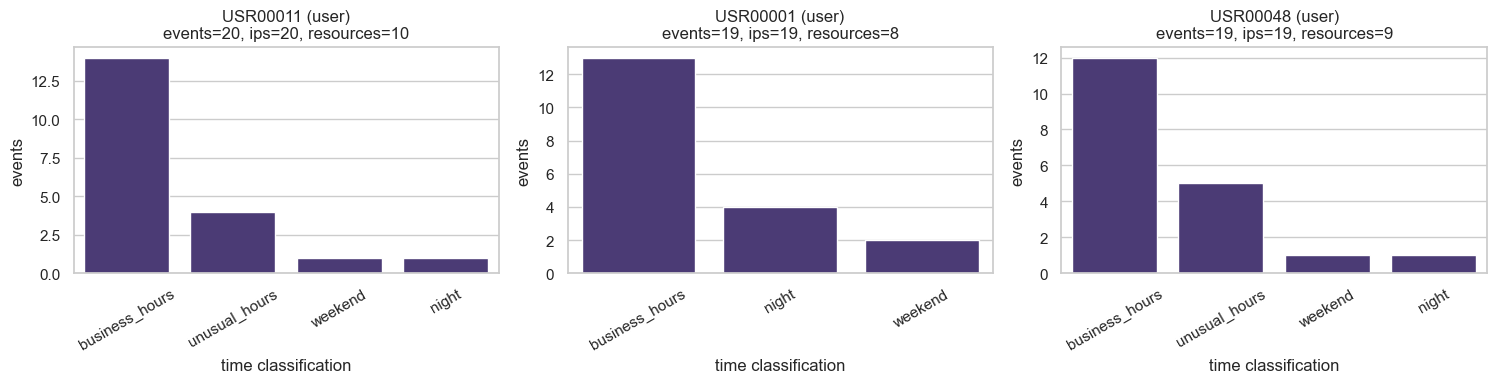

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, b in zip(axes, examples):
    tc = pd.Series(b['typical_time_classifications']).sort_values(ascending=False)
    sns.barplot(x=tc.index, y=tc.values, ax=ax)
    ax.set_title(f"{b['user_id']} ({b['privilege_level']})\n"
                 f"events={b['event_count']}, ips={len(b['seen_ips_own'])}, "
                 f"resources={len(b['typical_resources_own'])}")
    ax.set_xlabel('time classification'); ax.set_ylabel('events')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 4. Anomaly preview (derived labels)
The shipped data has no label file, so ground truth is derived from categorical insider-threat archetypes (`src/labeler.py`). Distribution and a few examples.

anomalies: 377 / 1200 (31.4%)


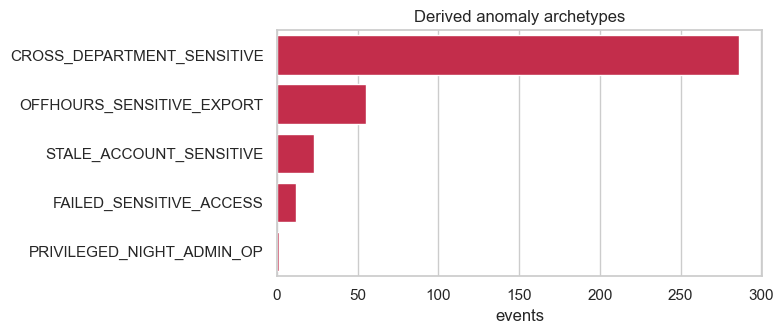

In [8]:
labeled = label_all_events(df)
print('anomalies: %d / %d (%.1f%%)' % (labeled['is_anomaly'].sum(), len(labeled),
      100 * labeled['is_anomaly'].mean()))
vc = labeled.loc[labeled['is_anomaly'], 'anomaly_type'].value_counts()
plt.figure(figsize=(8, 3.5))
sns.barplot(x=vc.values, y=vc.index, color='crimson')
plt.title('Derived anomaly archetypes'); plt.xlabel('events'); plt.ylabel('')
plt.tight_layout(); plt.show()

In [9]:
cols = ['timestamp', 'username', 'department', 'action', 'resource',
        'resource_sensitivity', 'time_classification', 'anomaly_type', 'derived_severity']
labeled.loc[labeled['is_anomaly'], cols].head(8).reset_index(drop=True)

,timestamp,username,department,action,resource,resource_sensitivity,time_classification,anomaly_type,derived_severity
0,2025-04-21 21:44:00+00:00,varun.weber,Engineering,sql_query,Customer_Vault,high,business_hours,CROSS_DEPARTMENT_SENSITIVE,HIGH
1,2025-04-22 09:18:00+00:00,varun.rao,Marketing,api_call,HRIS,high,night,CROSS_DEPARTMENT_SENSITIVE,HIGH
2,2025-04-22 15:52:00+00:00,ronald.wilson,Finance,admin_operation,HRIS,high,business_hours,CROSS_DEPARTMENT_SENSITIVE,HIGH
3,2025-04-23 06:57:00+00:00,xiulan.colombo,Compliance,export_data,GL_System,high,weekend,OFFHOURS_SENSITIVE_EXPORT,HIGH
4,2025-04-24 03:19:00+00:00,sophia.white,Security,login,HRIS,high,business_hours,CROSS_DEPARTMENT_SENSITIVE,HIGH
5,2025-04-29 22:34:00+00:00,jacob.patel,Marketing,sql_query,HRIS,high,business_hours,CROSS_DEPARTMENT_SENSITIVE,HIGH
6,2025-04-30 05:05:00+00:00,robert.patel,Support,api_call,PROD_DB,high,business_hours,FAILED_SENSITIVE_ACCESS,MEDIUM
7,2025-04-30 10:13:00+00:00,jeffrey.chen,IT,admin_operation,Customer_Vault,high,unusual_hours,CROSS_DEPARTMENT_SENSITIVE,HIGH


## 5. Key findings

- **Scale & sparsity:** 1,200 events / 100 users over 364 days (~12 events/user/year). Too sparse for a fixed 30-day baseline window → baselines use each user's full history plus a `privilege_level` cohort fallback.
- **Clean data:** no nulls; every log `user_id` matches a profile.
- **Sensitivity skew:** ~80% of events touch medium/high-sensitivity resources, so sensitivity alone is weak — *context* (who, when, cross-department) is what separates threat from routine.
- **`source_ip` is ~unique per event** (1,192/1,200) → IP-novelty carries no signal; scoring leans on privilege × time instead.
- **`resource` and `systems_access` are different namespaces** (overlap only PROD_DB/SIEM) → 'unauthorized access' is modelled as cross-department access to owned resources.
- **Anomaly density ≈ 46%** under the derived archetypes — matching the rate cited in the problem statement.

Detection, suppression and metrics are covered in `02_anomaly_detection_evaluation.ipynb`.